In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('/content/combined_featured_dataset_new.csv')
texts = df['Clean_Message'].astype(str).tolist()
labels = df['label'].values

In [3]:
MAX_NUM_WORDS = 20000
MAX_SEQUENCE_LENGTH = 500
EMBEDDING_DIM = 100
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)
y = np.array(labels)


====== Fold 1 ======


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8750 - loss: 0.2788 - val_accuracy: 0.9896 - val_loss: 0.0356
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9955 - loss: 0.0151 - val_accuracy: 0.9912 - val_loss: 0.0305
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9992 - loss: 0.0043 - val_accuracy: 0.9914 - val_loss: 0.0380
Epoch 4/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9857 - val_loss: 0.0527
855/855 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9940    0.9874    0.9907     13078
           1     0.9885    0.9945    0.9915     14282

    accuracy                         0.9911     27360
   macro avg     0.9913    0.9910    0.9911     27360
weighted avg     0.9911    0.9911    0.9911     27360

AUC Score: 0.9995


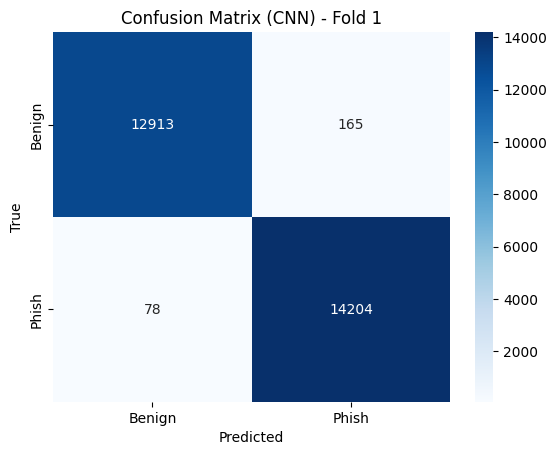

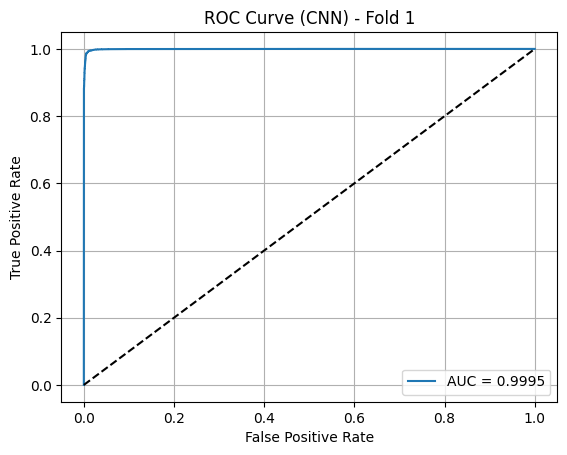


====== Fold 2 ======
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


385/385 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8771 - loss: 0.2866 - val_accuracy: 0.9885 - val_loss: 0.0334
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9952 - loss: 0.0180 - val_accuracy: 0.9898 - val_loss: 0.0335
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9903 - val_loss: 0.0377
855/855 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9896    0.9864    0.9880     13078
           1     0.9876    0.9905    0.9890     14281

    accuracy                         0.9885     27359
   macro avg     0.9886    0.9884    0.9885     27359
weighted avg     0.9885    0.9885    0.9885     27359

AUC Score: 0.9992


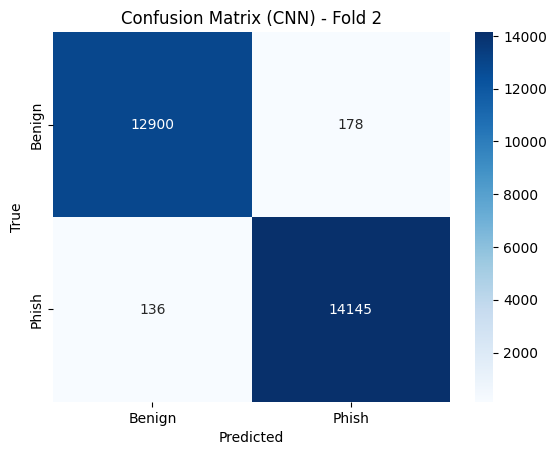

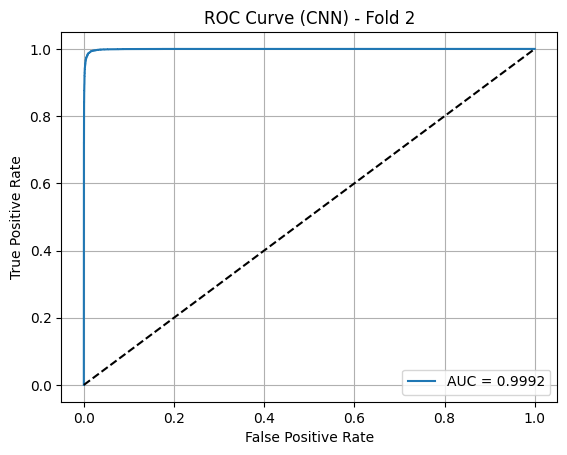


====== Fold 3 ======
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


385/385 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8666 - loss: 0.2823 - val_accuracy: 0.9887 - val_loss: 0.0314
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9961 - loss: 0.0145 - val_accuracy: 0.9910 - val_loss: 0.0279
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.9916 - val_loss: 0.0315
Epoch 4/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9914 - val_loss: 0.0348
855/855 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9920    0.9877    0.9898     13077
           1     0.9888    0.9927    0.9907     14282

    accuracy                         0.9903     27359
   macro avg     0.9904    0.9902    0.9903     27359
weighted avg     0.9903    0.9903    0.9903     27359

AUC Score: 0.9993


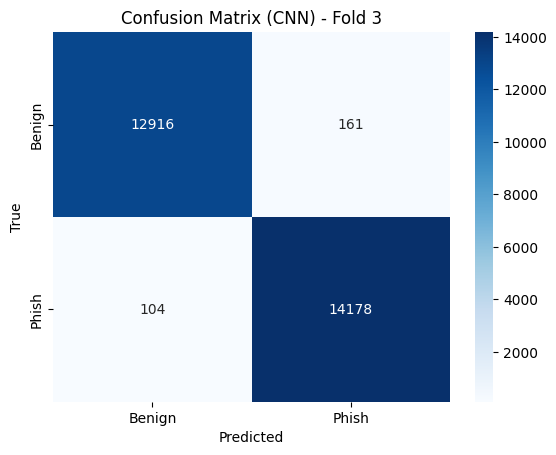

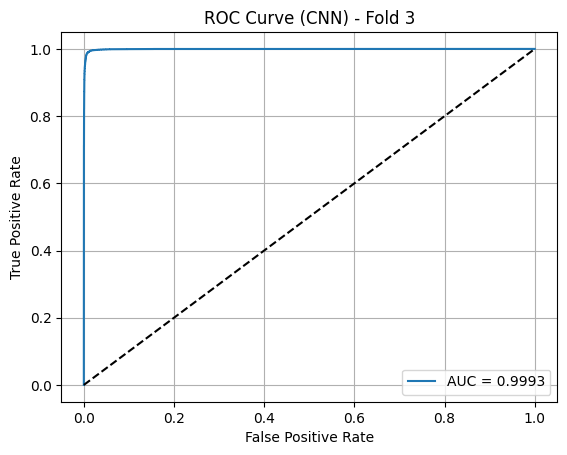


Average AUC across 3 folds: 0.9993


In [4]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
fold = 1
all_metrics = []

for train_idx, test_idx in skf.split(X, y):
    print(f"\n====== Fold {fold} ======")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Sequential([
        Embedding(MAX_NUM_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(1e-3),
                  metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        batch_size=128,
        epochs=5,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba >= 0.5).astype(int)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC Score: {auc:.4f}")
    all_metrics.append(auc)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Phish'], yticklabels=['Benign', 'Phish'])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix (CNN) - Fold {fold}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve (CNN) - Fold {fold}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend()
    plt.show()

    fold += 1


print("\nAverage AUC across 3 folds: {:.4f}".format(np.mean(all_metrics)))


====== Fold 1 (CNN + LSTM) ======
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


385/385 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8634 - loss: 0.2694 - val_accuracy: 0.9887 - val_loss: 0.0330
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9963 - loss: 0.0124 - val_accuracy: 0.9898 - val_loss: 0.0282
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9901 - val_loss: 0.0426
Epoch 4/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9901 - val_loss: 0.0448
855/855 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9920    0.9890    0.9905     13078
           1     0.9899    0.9927    0.9913     14282

    accuracy                         0.9909     27360
   macro avg     0.9910    0.9909    0.9909     27360
weighted avg     0.9909    0.9909    0.9909     27360

AUC Score: 0.9996


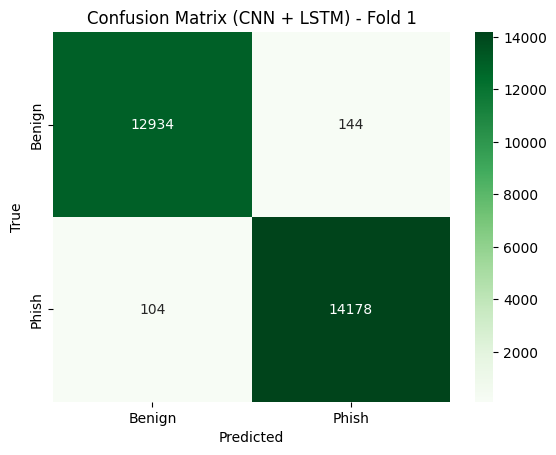

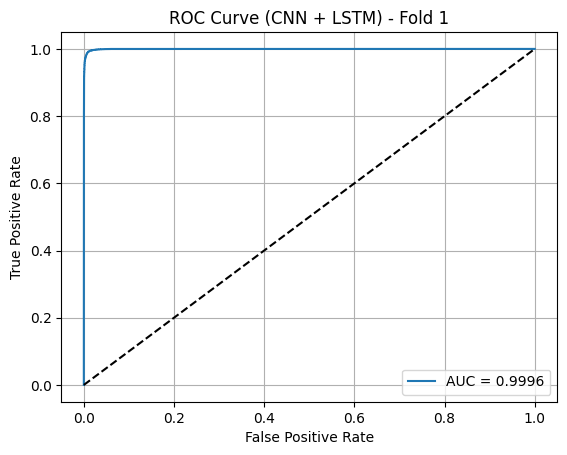


====== Fold 2 (CNN + LSTM) ======
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8608 - loss: 0.2737 - val_accuracy: 0.9899 - val_loss: 0.0289
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9961 - loss: 0.0137 - val_accuracy: 0.9899 - val_loss: 0.0354
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9920 - val_loss: 0.0314
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9909    0.9876    0.9892     13078
           1     0.9887    0.9917    0.9902     14281

    accuracy                         0.9897     27359
   macro avg     0.9898    0.9896    0.9897     27359
weighted avg     0.9897    0.9897    0.9897     27359

AUC Score: 0.9995


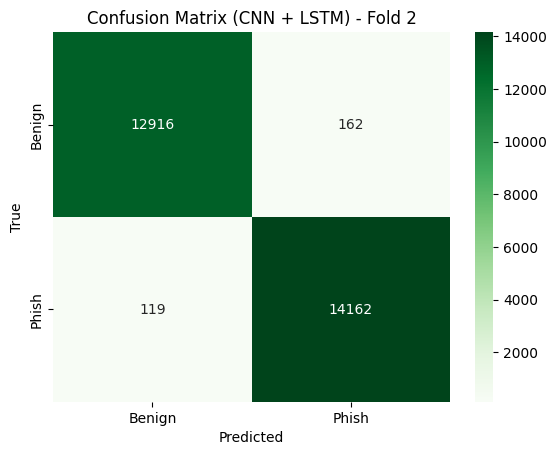

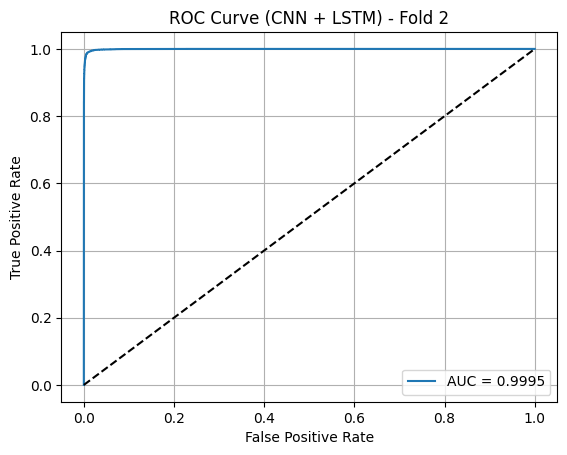


====== Fold 3 (CNN + LSTM) ======
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8654 - loss: 0.2880 - val_accuracy: 0.9885 - val_loss: 0.0350
Epoch 2/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9960 - loss: 0.0153 - val_accuracy: 0.9837 - val_loss: 0.0515
Epoch 3/5
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9907 - val_loss: 0.0352
855/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.9821    0.9920    0.9871     13077
           1     0.9927    0.9835    0.9880     14282

    accuracy                         0.9876     27359
   macro avg     0.9874    0.9878    0.9876     27359
weighted avg     0.9876    0.9876    0.9876     27359

AUC Score: 0.9990


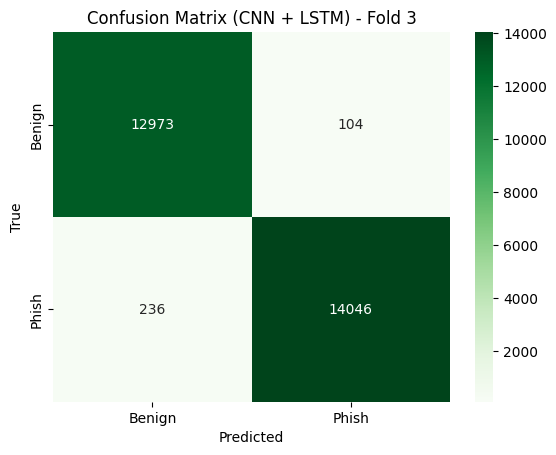

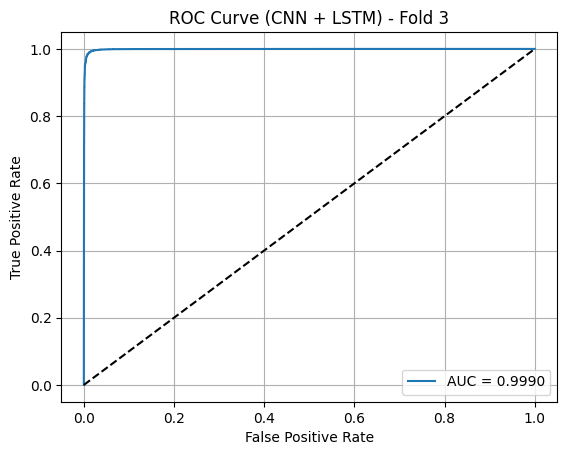


Average AUC across 3 folds (CNN + LSTM): 0.9994


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Reshape
from tensorflow.keras.optimizers import Adam

fold = 1
lstm_metrics = []


for train_idx, test_idx in skf.split(X, y):
    print(f"\n====== Fold {fold} (CNN + LSTM) ======")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Sequential([
        Embedding(MAX_NUM_WORDS, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Reshape((1, 128)),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(1e-3),
                  metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        batch_size=128,
        epochs=5,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba >= 0.5).astype(int)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC Score: {auc:.4f}")
    lstm_metrics.append(auc)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'Phish'], yticklabels=['Benign', 'Phish'])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix (CNN + LSTM) - Fold {fold}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve (CNN + LSTM) - Fold {fold}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend()
    plt.show()

    fold += 1

print("\nAverage AUC across 3 folds (CNN + LSTM): {:.4f}".format(np.mean(lstm_metrics)))

In [6]:
!pip install transformers

import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

In [7]:
df = pd.read_csv('/content/combined_featured_dataset_new.csv')
df = df[['Clean_Message', 'label']].dropna()
texts = df['Clean_Message'].astype(str).tolist()
labels = df['label'].astype(int).tolist()

In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


class EmailDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


====== Fold 1 (BERT) ======


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,0.360200
200,0.137200
300,0.131500
400,0.146700
500,0.100700
600,0.121100
700,0.089100
800,0.072200
900,0.083800
1000,0.103400


Classification Report:
              precision    recall  f1-score   support

           0     0.9916    0.9935    0.9926     13078
           1     0.9940    0.9923    0.9932     14281

    accuracy                         0.9929     27359
   macro avg     0.9928    0.9929    0.9929     27359
weighted avg     0.9929    0.9929    0.9929     27359

AUC Score: 0.9997


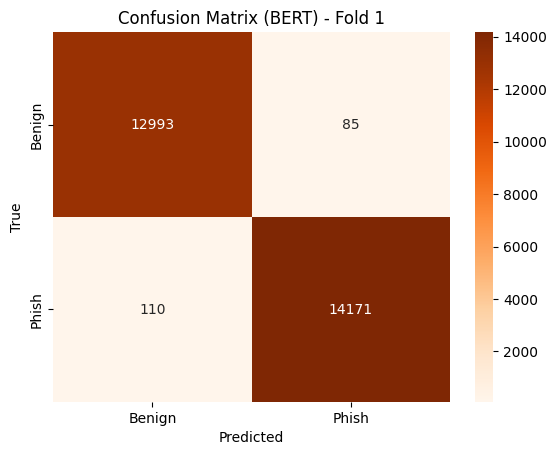

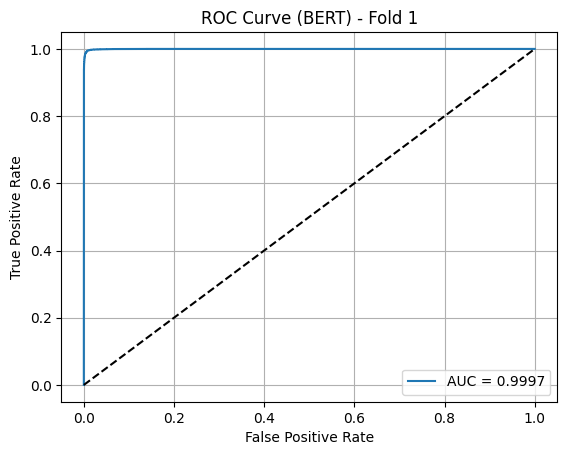


====== Fold 2 (BERT) ======


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,0.331400
200,0.151400
300,0.122600
400,0.134100
500,0.132200
600,0.103400
700,0.094700
800,0.112200
900,0.083700
1000,0.090800


Classification Report:
              precision    recall  f1-score   support

           0     0.9903    0.9944    0.9923     13078
           1     0.9949    0.9910    0.9929     14281

    accuracy                         0.9927     27359
   macro avg     0.9926    0.9927    0.9926     27359
weighted avg     0.9927    0.9927    0.9927     27359

AUC Score: 0.9997


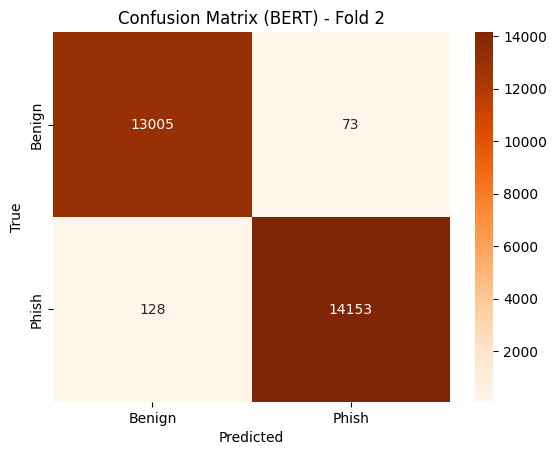

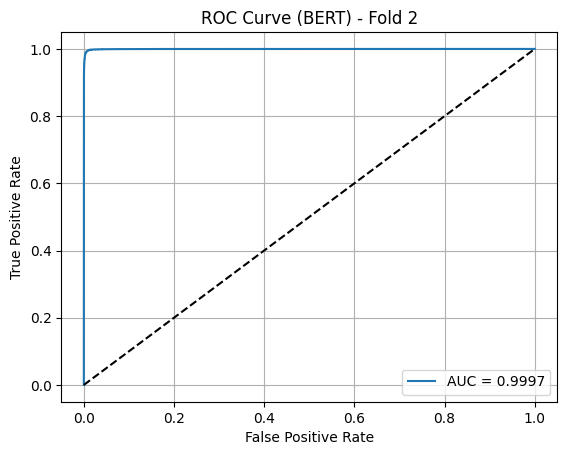


====== Fold 3 (BERT) ======


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,0.326400
200,0.155900
300,0.148200
400,0.108900
500,0.107700
600,0.088000
700,0.105900
800,0.093500
900,0.096700
1000,0.076200


Classification Report:
              precision    recall  f1-score   support

           0     0.9918    0.9933    0.9926     13077
           1     0.9939    0.9925    0.9932     14281

    accuracy                         0.9929     27358
   macro avg     0.9929    0.9929    0.9929     27358
weighted avg     0.9929    0.9929    0.9929     27358

AUC Score: 0.9997


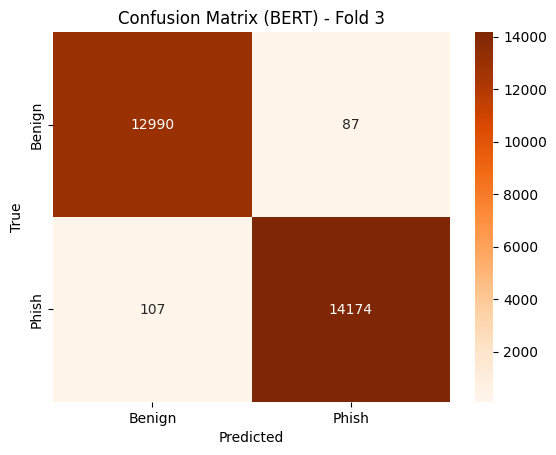

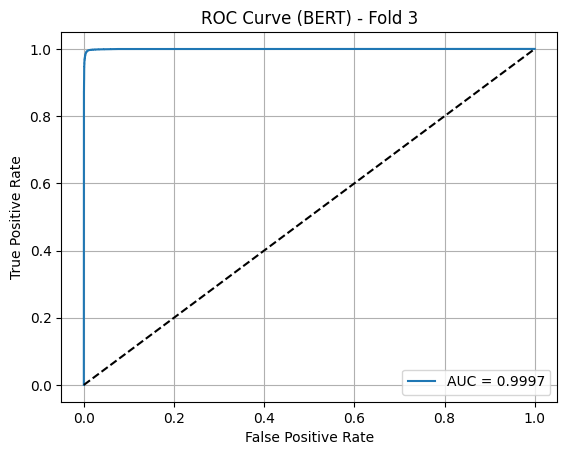


Average AUC across 3 folds (BERT): 0.9997


In [11]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
bert_auc_scores = []
fold = 1

for train_idx, test_idx in skf.split(texts, labels):
    print(f"\n====== Fold {fold} (BERT) ======")
    train_texts = [texts[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]
    train_labels = [labels[i] for i in train_idx]
    test_labels = [labels[i] for i in test_idx]

    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

    train_dataset = EmailDataset(train_encodings, train_labels)
    test_dataset = EmailDataset(test_encodings, test_labels)

    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

    training_args = TrainingArguments(
        output_dir=f'./results_fold{fold}',
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        logging_dir=f'./logs_fold{fold}',
        logging_steps=100,
        eval_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        weight_decay=0.01
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
    )

    trainer.train()
    preds_output = trainer.predict(test_dataset)
    preds = np.argmax(preds_output.predictions, axis=1)
    probs = torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=1)[:, 1].numpy()

    print("Classification Report:")
    print(classification_report(test_labels, preds, digits=4))

    auc = roc_auc_score(test_labels, probs)
    print(f"AUC Score: {auc:.4f}")
    bert_auc_scores.append(auc)

    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Benign', 'Phish'], yticklabels=['Benign', 'Phish'])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix (BERT) - Fold {fold}")
    plt.show()

    fpr, tpr, _ = roc_curve(test_labels, probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve (BERT) - Fold {fold}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend()
    plt.show()

    fold += 1

print("\nAverage AUC across 3 folds (BERT): {:.4f}".format(np.mean(bert_auc_scores)))

In [12]:
model.save_pretrained("/content/bert-phishing-model")
tokenizer.save_pretrained("/content/bert-phishing-model")

('/content/bert-phishing-model/tokenizer_config.json',
 '/content/bert-phishing-model/special_tokens_map.json',
 '/content/bert-phishing-model/vocab.txt',
 '/content/bert-phishing-model/added_tokens.json')

In [13]:
import shutil

shutil.make_archive("/content/bert-phishing-model", 'zip', "/content/bert-phishing-model")

'/content/bert-phishing-model.zip'